In [1]:
from datasetEmociones import *
from transformer import *
from torch.utils.data import Dataset, DataLoader
import numpy as np
from utils import *
import matplotlib.pyplot as plt

In [2]:
train_transformer_dataset = EmotionDataset(ANNOTATIONS_FILE,
                AUDIO_DIR, 
                data_portion='train',
                transform=transformer_transform
                )

val_transformer_dataset = EmotionDataset(ANNOTATIONS_FILE,
                AUDIO_DIR, 
                data_portion='validation',
                transform=transformer_transform
                )

Época: 1
LOSS train 17.382112503051758 valid 11.975800514221191
Modelo guardado en epoca 1
Época: 2
LOSS train 7.712681770324707 valid 4.739834308624268
Modelo guardado en epoca 2
Época: 3
LOSS train 3.1742286682128906 valid 2.0426487922668457
Modelo guardado en epoca 3
Época: 4
LOSS train 1.5119426250457764 valid 1.1609339714050293
Modelo guardado en epoca 4
Época: 5
LOSS train 1.061676025390625 valid 1.0216269493103027
Modelo guardado en epoca 5
Época: 6
LOSS train 0.9974506497383118 valid 1.0079047679901123
Modelo guardado en epoca 6
Época: 7
LOSS train 0.9949147701263428 valid 1.009910225868225
Época: 8
LOSS train 0.9957129955291748 valid 1.015285611152649
Época: 9
LOSS train 0.9933630228042603 valid 1.0130256414413452
Época: 10
LOSS train 0.9949369430541992 valid 1.0096807479858398
Época: 11
LOSS train 0.994064211845398 valid 1.0096564292907715
Época: 12
LOSS train 0.9937505722045898 valid 1.0094854831695557
Época: 13
LOSS train 0.9953010082244873 valid 1.0103235244750977
Época: 1

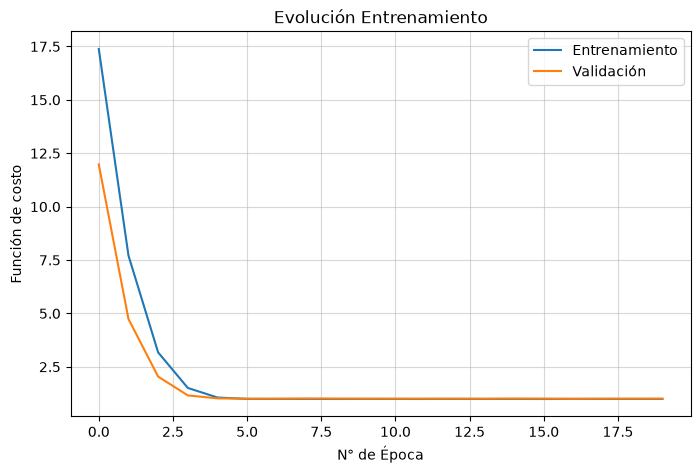

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# modelo
model = CustomTransformer(D_pos_emb=50).to(device)

# hiperparámetros
learning_rate = 1e-4
batch_size = 64
epochs = 20

# nombre de archivo con parametros
parameters_file = 'Transformer_params.pt'

# funcion de perdida
loss_fn = nn.MSELoss()

# optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# dataloaders
train_dataloader = DataLoader(train_transformer_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_transformer_dataset, batch_size=batch_size, shuffle=True)

# listas para almacenar la evolución del loss en train y validacion
train_loss_evol = []
val_loss_evol = []

# se inicializan variables del entrenamiento
best_vloss = np.inf

# loop de entrenamiento
for epoch in range(epochs):
    print(f'Época: {epoch + 1}')

    # se realiza el entrenamiento
    model.train()
    avg_loss = train_one_epoch(model, train_dataloader, optimizer, loss_fn, device)

    # se evalua el modelo en validacion
    model.eval()
    avg_vloss = get_val_loss(model, val_dataloader, loss_fn, device)

    # se guardan e imprimen los loss de entrenamiento y validacion
    train_loss_evol.append(avg_loss)
    val_loss_evol.append(avg_vloss)
    print(f'LOSS train {avg_loss} valid {avg_vloss}')

    # se guarda el mejor modelo considerando la loss en validacion
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        # se guardan los parametros con menor loss en validacion
        torch.save(model.state_dict(), parameters_file)
        print(f'Modelo guardado en epoca {epoch+1}')

# se grafica la evolucion de la funcion de costo a lo largo de las epocas
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(train_loss_evol, label = 'Entrenamiento')
ax.plot(val_loss_evol, label = 'Validación')
ax.set(xlabel='N° de Época', ylabel='Función de costo', title='Evolución Entrenamiento')
ax.grid(alpha = 0.5)
ax.legend()
plt.show()